# Proyecto Final 1

- Clases: background, track, kart, pickup, nitro, bomb, projectile.
- Targets: tipo Long y valores de clase sin escalar.
- Perdida: CrossEntropyLoss con class weights.
- Datos: posible desbalance fuerte entre clases.
- Seguimiento: metricas y visualizaciones por epoca en TensorBoard.

In [1]:
from __future__ import annotations

import os
import random
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, display
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

torch.set_float32_matmul_precision("high")

PROJECT_ROOT = Path.cwd().parents[1]
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from settings import DATA_DIR, LOGS_DIR
from dataset import CLASS_NAMES, DEFAULT_COLORS, DenseSegmentationDataModule
from sam2_model import SAM2TransferLightningModule
from visualization import colorize_mask, list_available_frames, load_sample, render_video_frame

L.seed_everything(42, workers=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Logs dir: {LOGS_DIR}")

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DMI: DGXH200
Environment detected: VSCode Remote
DataLoader num_workers set to: 2
Progress bar set to False


Seed set to 42


Project root: /home/docampor/usfq-mmia
Data dir: /home/docampor/usfq-mmia/data
Logs dir: /home/docampor/usfq-mmia/logs


## Configuracion del dataset
- Reutilizamos DenseSegmentationDataModule sin reescribir logica de carga y augmentations. Es lo mismo que usé para el taller 2.
- Usamos split validación con control de presencia de clases minoritarias.
- Extraemos class weights desde el mismo DataModule para la CrossEntropy ponderada.

In [5]:
BATCH_SIZE = 16
CROP_SIZE = 256
VAL_FRACTION = 0.2
VAL_MINORITY_FRACTION = 0.5
MAX_EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 10
SAM2_CONFIG_NAME = "sam2.1_hiera_l.yaml"
SAM2_CHECKPOINT_NAME = "sam2.1_hiera_large.pt"
SAM2_DEVICE = "cuda:3"
TRAIN_GPU_DEVICE = [3]
EXPERIMENT_NAME = "sam2-transfer-heavy-h200"

@dataclass
class RunConfig:
    batch_size: int
    crop_size: int
    val_fraction: float
    val_minority_fraction: float
    max_epochs: int
    learning_rate: float
    weight_decay: float
    patience: int
    sam2_config_name: str
    sam2_checkpoint_name: str
    sam2_device: str
    train_gpu_device: list[int]
    experiment_name: str

config = RunConfig(
    batch_size=BATCH_SIZE,
    crop_size=CROP_SIZE,
    val_fraction=VAL_FRACTION,
    val_minority_fraction=VAL_MINORITY_FRACTION,
    max_epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    sam2_config_name=SAM2_CONFIG_NAME,
    sam2_checkpoint_name=SAM2_CHECKPOINT_NAME,
    sam2_device=SAM2_DEVICE,
    train_gpu_device=TRAIN_GPU_DEVICE,
    experiment_name=EXPERIMENT_NAME,
)

print(config)

RunConfig(batch_size=16, crop_size=256, val_fraction=0.2, val_minority_fraction=0.5, max_epochs=100, learning_rate=0.0003, weight_decay=0.0001, patience=10, sam2_config_name='sam2.1_hiera_l.yaml', sam2_checkpoint_name='sam2.1_hiera_large.pt', sam2_device='cuda:3', train_gpu_device=[3], experiment_name='sam2-transfer-heavy-h200')


In [3]:
datamodule = DenseSegmentationDataModule(
    data_root=DATA_DIR / "dense_data",
    batch_size=config.batch_size,
    crop_size=config.crop_size,
    val_fraction=config.val_fraction,
    val_minority_fraction=config.val_minority_fraction,
    seed=42,
)

datamodule.prepare_data()
datamodule.setup("fit")

print(f"Train samples: {len(datamodule.train_samples)}")
print(f"Val samples: {len(datamodule.val_samples)}")
print(f"Missing masks: {len(datamodule.missing_masks)}")
print("Class names:", CLASS_NAMES)
print("Class counts:", datamodule.class_counts.tolist())
print("Class weights:", [round(float(v), 4) for v in datamodule.class_weights.tolist()])

Train samples: 1200
Val samples: 300
Missing masks: 0
Class names: ['background', 'track', 'kart', 'pickup', 'nitro', 'bomb', 'projectile']
Class counts: [98341690, 88999276, 4262940, 249939, 37508, 92050, 16597]
Class weights: [0.0374, 0.0394, 0.1798, 0.7425, 1.9124, 1.2226, 2.8658]


## Modelo SAM2 con Lightning
- Backbone SAM2 congelado y decoder pequeno entrenable. El codigo completo esta en `sam2_model.py`.
- Metricas de evaluacion: loss, IoU, accuracy macro, accuracy por clase y pixel accuracy.
- Visualizacion fija por epoca en TensorBoard para seguir evolucion cualitativa.

In [6]:
model = SAM2TransferLightningModule(
    sam2_config_name=config.sam2_config_name,
    sam2_checkpoint_name=config.sam2_checkpoint_name,
    sam2_device=config.sam2_device,
    num_classes=len(CLASS_NAMES),
    learning_rate=config.learning_rate,
    weight_decay=config.weight_decay,
    class_weights=datamodule.class_weights,
    visual_log_every_n_epochs=1,
)

fixed_images, fixed_masks, fixed_meta = datamodule.fixed_validation_subset(n_samples=5)
model.set_fixed_validation_samples(fixed_images, fixed_masks)

logger = TensorBoardLogger(
    save_dir=str(LOGS_DIR),
    name=config.experiment_name,
    default_hp_metric=False,
)
logger.log_hyperparams({
    "batch_size": config.batch_size,
    "crop_size": config.crop_size,
    "val_fraction": config.val_fraction,
    "val_minority_fraction": config.val_minority_fraction,
    "max_epochs": config.max_epochs,
    "learning_rate": config.learning_rate,
    "weight_decay": config.weight_decay,
    "patience": config.patience,
    "sam2_config_name": config.sam2_config_name,
    "sam2_checkpoint_name": config.sam2_checkpoint_name,
    "sam2_device": config.sam2_device,
    "train_gpu_device": config.train_gpu_device,
})

checkpoint_callback = ModelCheckpoint(
    monitor="val_mean_iou",
    mode="max",
    save_top_k=1,
    save_last=True,
    filename="sam2-transfer-heavy-e{epoch:02d}-miou{val_mean_iou:.4f}",
    auto_insert_metric_name=False,
)

early_stop = EarlyStopping(
    monitor="val_mean_iou",
    mode="max",
    patience=config.patience,
    verbose=True,
)

trainer = L.Trainer(
    max_epochs=config.max_epochs,
    logger=logger,
    callbacks=[checkpoint_callback, early_stop],
    accelerator="gpu",
    devices=config.train_gpu_device,
    precision="16-mixed",
    log_every_n_steps=5,
    num_sanity_val_steps=1,
)

print("TensorBoard log dir:", logger.log_dir)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


TensorBoard log dir: /home/docampor/usfq-mmia/logs/sam2-transfer-heavy-h200/version_0


## Entrenamiento

In [7]:
trainer.fit(model=model, datamodule=datamodule)

best_ckpt_path = checkpoint_callback.best_model_path
print(f"Best checkpoint: {best_ckpt_path}")
print(f"Last checkpoint: {checkpoint_callback.last_model_path}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]
/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ sam2_model          │ SAM2Base               │  224 M │ eval  │     0 │
│ 1  │ decoder             │ SimpleSAM2Decoder      │  369 K │ train │     0 │
│ 2  │ train_iou_macro     │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 3  │ val_iou_macro       │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 4  │ train_iou_per_class │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 5  │ val_iou_per_class   │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 6  │ train_acc_macro     │ MulticlassAccuracy     │      0 │ train │     0 │
│ 7  │ val_acc_macro       │ MulticlassAccuracy     │      0 │ train │     0 │
│ 8  │ train_acc_per_class │ MulticlassAccuracy     │      0 │ train │     0 │
│ 9  │ val_acc_per_class   │ MulticlassAccuracy     │      0 │ train │     0 │
│ 10 │ train_acc_micro     │ MulticlassAccuracy     │      0 │ train │     0 │
│ 11 │ val_acc_micro       │ MulticlassAccuracy     │      0 │ train │     0 │
└────┴─────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 369 K                                                                                            
Non-trainable params: 224 M                                                                                        
Total params: 224 M                                                                                                
Total estimated model params size (MB): 899                                                                        
Modules in train mode: 17                                                                                          
Modules in eval mode: 850                                                                                          
Total FLOPs: 0

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/docampor/usfq-mmia/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 850 
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

Metric val_mean_iou improved. New best score: 0.399
Metric val_mean_iou improved by 0.047 >= min_delta = 0.0. New best score: 0.446
Metric val_mean_iou improved by 0.020 >= min_delta = 0.0. New best score: 0.466
Metric val_mean_iou improved by 0.060 >= min_delta = 0.0. New best score: 0.527
Metric val_mean_iou improved by 0.017 >= min_delta = 0.0. New best score: 0.544
Metric val_mean_iou improved by 0.009 >= min_delta = 0.0. New best score: 0.553
Metric val_mean_iou improved by 0.003 >= min_delta = 0.0. New best score: 0.556
Metric val_mean_iou improved by 0.043 >= min_delta = 0.0. New best score: 0.599
Metric val_mean_iou improved by 0.090 >= min_delta = 0.0. New best score: 0.689
Monitored metric val_mean_iou did not improve in the last 10 records. Best score: 0.689. Signaling Trainer to stop.


Best checkpoint: /home/docampor/usfq-mmia/logs/sam2-transfer-heavy-h200/version_0/checkpoints/sam2-transfer-heavy-e22-miou0.6894.ckpt
Last checkpoint: /home/docampor/usfq-mmia/logs/sam2-transfer-heavy-h200/version_0/checkpoints/last.ckpt


## TensorBoard

In [9]:
%load_ext tensorboard
%tensorboard --logdir {LOGS_DIR} --port 6017

In [10]:
if not best_ckpt_path:
    raise RuntimeError("No se encontro best checkpoint. Verifica el entrenamiento.")

best_model = SAM2TransferLightningModule.load_from_checkpoint(
    best_ckpt_path,
    map_location="cpu",
    class_weights=None,
)

export_dir = LOGS_DIR / config.experiment_name / "exports"
export_dir.mkdir(parents=True, exist_ok=True)
state_th_path = export_dir / "sam2_transfer_model.th"
torch.save(best_model.state_dict(), state_th_path)

print(f"Exported .th model: {state_th_path}")

Exported .th model: /home/docampor/usfq-mmia/logs/sam2-transfer-heavy-h200/exports/sam2_transfer_model.th


## Ejemplo de inferencia

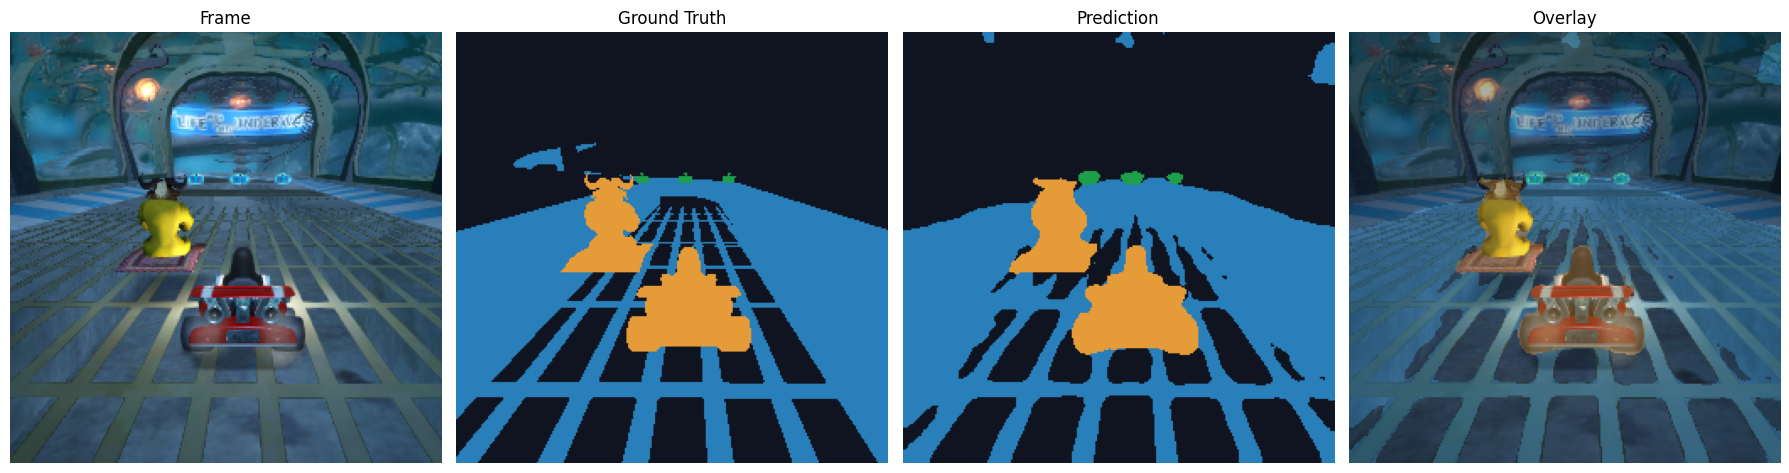

In [11]:
def denormalize_image(image: torch.Tensor) -> np.ndarray:
    """Convert normalized CHW tensor to HWC RGB image in [0, 1]."""

    mean = torch.tensor([0.485, 0.456, 0.406], dtype=image.dtype, device=image.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=image.dtype, device=image.device).view(3, 1, 1)
    output = image * std + mean
    output = torch.clamp(output, 0.0, 1.0)
    return output.permute(1, 2, 0).cpu().numpy()


def render_single_result(image: torch.Tensor, ground_truth: np.ndarray, prediction: np.ndarray) -> None:
    """Plot frame, ground truth, prediction, and overlay."""

    image_rgb = denormalize_image(image)
    gt_color = colorize_mask(ground_truth)
    pred_color = colorize_mask(prediction)
    overlay = np.clip(0.65 * image_rgb + 0.35 * (pred_color / 255.0), 0.0, 1.0)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(image_rgb)
    axes[0].set_title("Frame")
    axes[1].imshow(gt_color)
    axes[1].set_title("Ground Truth")
    axes[2].imshow(pred_color)
    axes[2].set_title("Prediction")
    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")

    for axis in axes:
        axis.axis("off")
    fig.tight_layout()
    plt.show()

best_model = best_model.to("cpu")
best_model.eval()

sample_image, sample_mask = datamodule.val_dataset[0]  # type: ignore[index]
with torch.no_grad():
    logits = best_model(sample_image.unsqueeze(0).to(best_model.device))
    logits = torch.nn.functional.interpolate(
        logits,
        size=sample_mask.shape,
        mode="bilinear",
        align_corners=False,
    )
    sample_pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

render_single_result(sample_image, sample_mask.numpy(), sample_pred)

## Grid de resultados aleatorios

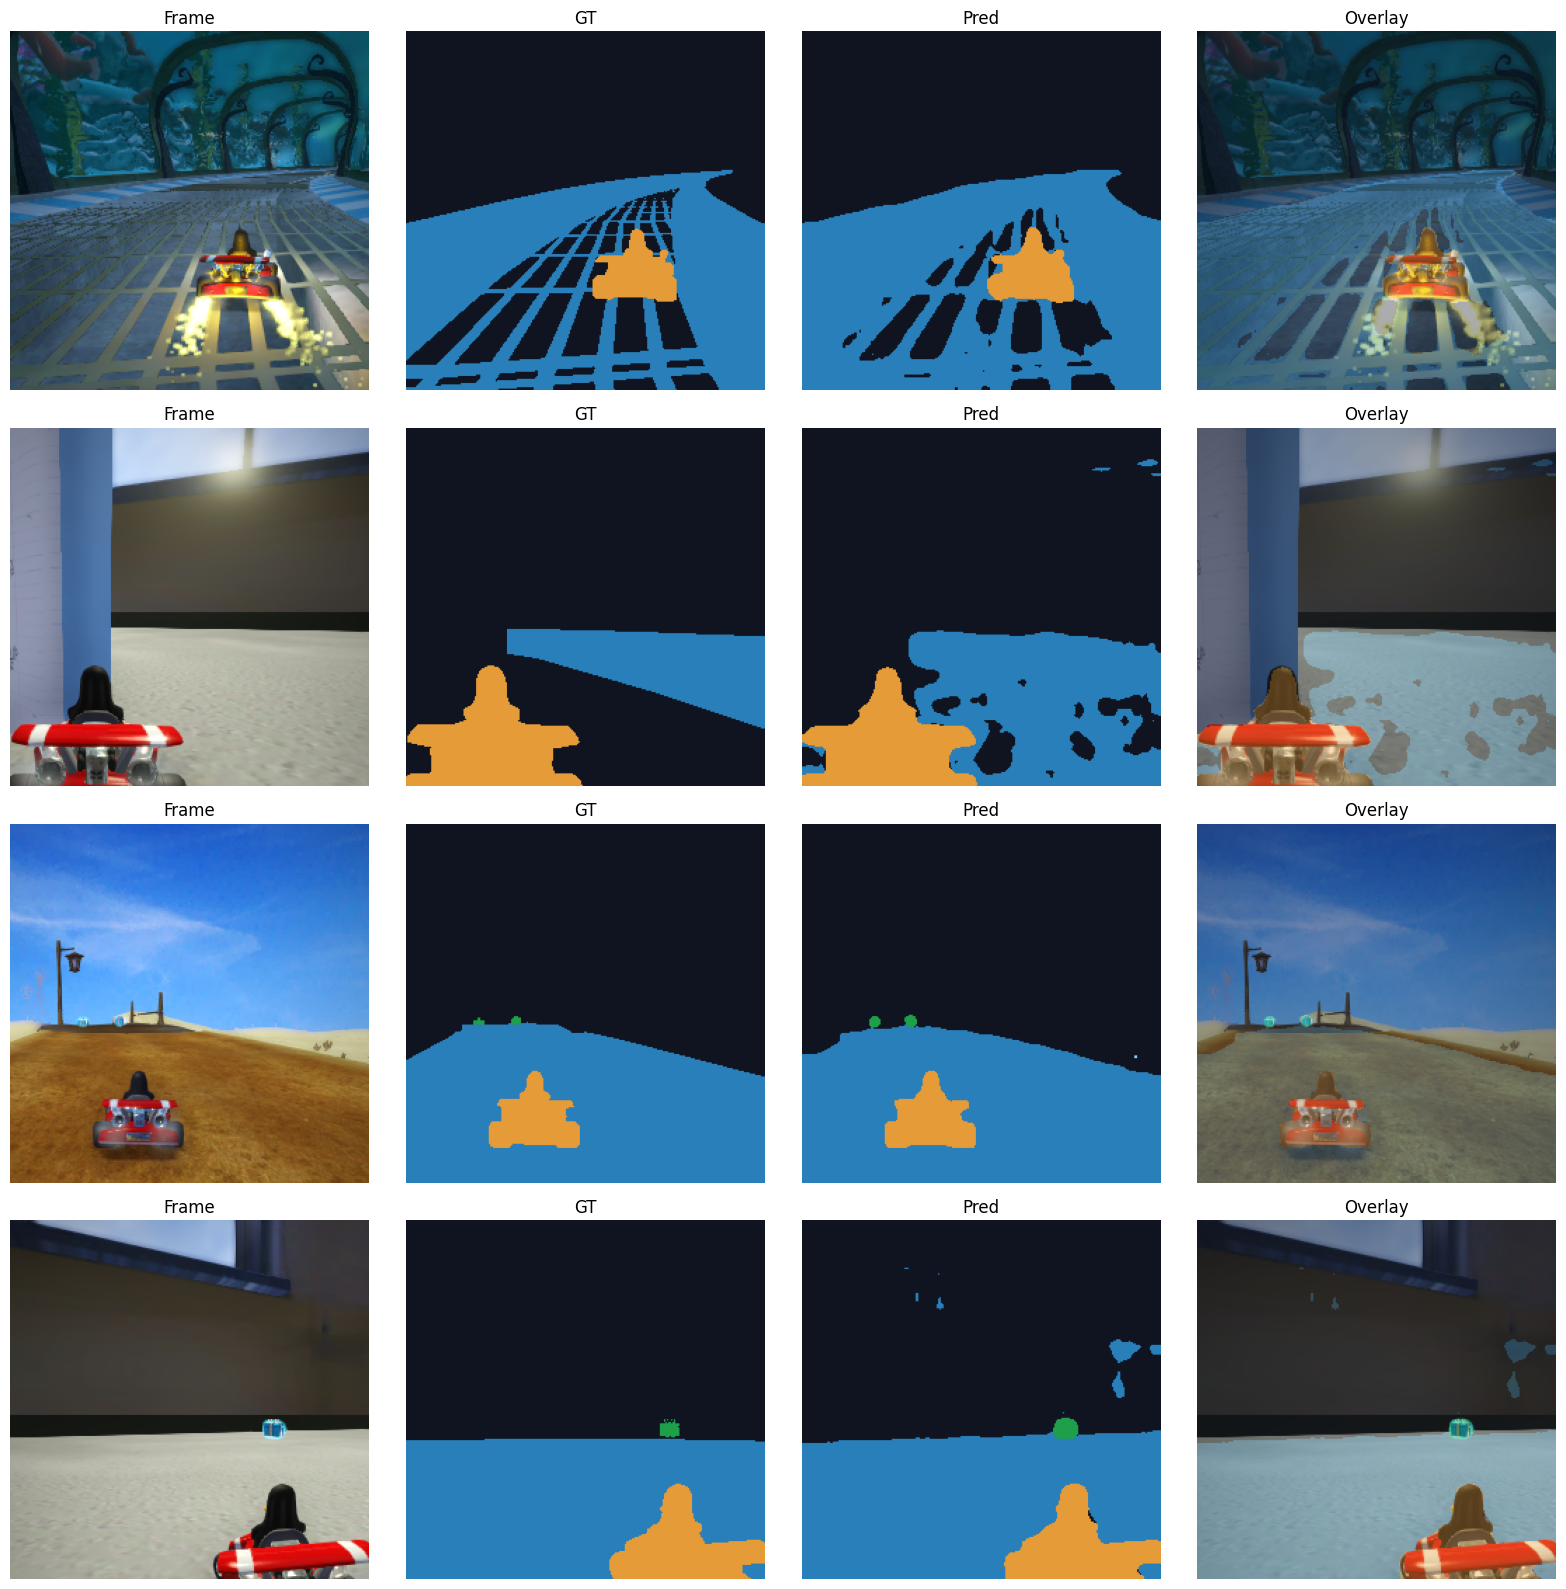

In [12]:
def predict_mask(image: torch.Tensor, model: SAM2TransferLightningModule) -> np.ndarray:
    """Predict one class-index mask for a normalized image tensor."""

    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(model.device))
        logits = torch.nn.functional.interpolate(
            logits,
            size=image.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
    return torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()


def render_panel(image: torch.Tensor, mask: np.ndarray, pred: np.ndarray, ax_row: list[Any]) -> None:
    """Render frame, gt, pred, overlay on one row of axes."""

    frame = denormalize_image(image)
    gt = colorize_mask(mask)
    pd = colorize_mask(pred)
    ov = np.clip(0.65 * frame + 0.35 * (pd / 255.0), 0.0, 1.0)

    ax_row[0].imshow(frame)
    ax_row[0].set_title("Frame")
    ax_row[1].imshow(gt)
    ax_row[1].set_title("GT")
    ax_row[2].imshow(pd)
    ax_row[2].set_title("Pred")
    ax_row[3].imshow(ov)
    ax_row[3].set_title("Overlay")
    for axis in ax_row:
        axis.axis("off")


rng = np.random.default_rng(42)
val_indices = rng.choice(len(datamodule.val_dataset), size=min(4, len(datamodule.val_dataset)), replace=False)  # type: ignore[arg-type]
fig, axes = plt.subplots(len(val_indices), 4, figsize=(16, 4 * len(val_indices)))
if len(val_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, sample_idx in enumerate(val_indices.tolist()):
    image_t, mask_t = datamodule.val_dataset[sample_idx]  # type: ignore[index]
    pred_t = predict_mask(image_t, best_model)
    render_panel(image_t, mask_t.numpy(), pred_t, list(axes[row_idx]))

fig.tight_layout()
plt.show()

## GIFs de tracks

In [13]:
from PIL import Image as PILImage

def generate_track_gif(
    model: SAM2TransferLightningModule,
    track: str,
    frame_ids: list[int],
    gif_path: Path,
    fps: int = 4,
) -> Path:
    """Generate a simple GIF for one track."""

    rendered: list[PILImage.Image] = []
    for frame_id in frame_ids:
        image_t, mask_np = load_sample(track=track, frame_id=frame_id)
        pred_np = predict_mask(image_t, model)
        panel = render_video_frame(image_t, mask_np, pred_np)
        rendered.append(PILImage.fromarray(panel))

    gif_path.parent.mkdir(parents=True, exist_ok=True)
    duration_ms = int(1000 / max(1, fps))
    rendered[0].save(
        gif_path,
        save_all=True,
        append_images=rendered[1:],
        duration=duration_ms,
        loop=0,
    )
    return gif_path


available_tracks = sorted([p.name for p in (DATA_DIR / "dense_data").iterdir() if p.is_dir()])
selected_tracks = available_tracks[:2]

gif_output_dir = LOGS_DIR / config.experiment_name / "gifs"
generated_gifs: list[Path] = []
for track_name in selected_tracks:
    valid_ids = list_available_frames(track_name)
    chosen_ids = valid_ids[:: max(1, len(valid_ids) // 8)][:8]
    if len(chosen_ids) < 2:
        continue
    gif_file = gif_output_dir / f"{track_name}.gif"
    generated_gifs.append(generate_track_gif(best_model, track_name, chosen_ids, gif_file, fps=4))

for gif_path in generated_gifs:
    print(gif_path)
    display(HTML(f"<img src='{gif_path.as_posix()}' style='max-width:100%;height:auto;' />"))

/home/docampor/usfq-mmia/logs/sam2-transfer-heavy-h200/gifs/abyss.gif


/home/docampor/usfq-mmia/logs/sam2-transfer-heavy-h200/gifs/gran_paradiso_island.gif


## Resultados


## Presentacion con Gradio
- La app permite seleccionar checkpoints y navegar frames rapidamente.
- Incluye panel de metricas y export de GIF por track.
- Incluye tab de highlights para explicar decisiones tecnicas.

In [ ]:
import importlib
import sam2_presentation as sam2_presentation_module

sam2_presentation_module = importlib.reload(sam2_presentation_module)
presentation_app, presentation_css = sam2_presentation_module.build_app()
presentation_app.launch(css=presentation_css)